In [3]:
import scipy.io as sio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from rich.console import Console
from rich.table import Table
from rich.progress import track

Caricamento e visualizzazione dei canali

In [4]:
print("Caricamento del file CSV in corso...")

# 1. LA MAGIA SALVA-VITA: usiamo 'nrows' per leggere solo le prime 10.000 righe
# (Ricordati di inserire il percorso o il nome esatto del file che hai scaricato)
dfg = pd.read_csv('training.csv', nrows=10000)

df = dfg.drop(['EventId','Weight'], axis=1)

print(f"Fatto! Dimensioni della tabella: {df.shape} (righe, colonne)\n")

# 2. SEPARIAMO I DATI (X) DALLE ETICHETTE (y)
# Nei dataset pubblici come quello di Kaggle, di solito l'ULTIMA colonna 
# contiene la risposta (es. 1 per il Bosone di Higgs, 0 per il rumore).

# Prendi tutte le righe (:), e tutte le colonne tranne l'ultima (:-1)
X = df.iloc[:, :-1].values 

# Prendi tutte le righe (:), ma SOLO l'ultima colonna (-1)
y = df.iloc[:, -1].map({'s': 1, 'b': 0}).values

print("Inizio la preparazione finale dei dati...")

# 1. DISINNESCHIAMO LA TRAPPOLA DEI -999.0
# Diciamo a Numpy di convertire tutti i -999.0 in veri valori "mancanti" (NaN)
X[X == -999.0] = np.nan

# Ora usiamo un 'Imputer': uno strumento magico che cerca i NaN 
# e li sostituisce con il valore Mediano di quella specifica colonna
imputer = SimpleImputer(strategy='median')
X_pulito = imputer.fit_transform(X)

print("Valori mancanti (-999.0) sistemati con successo!")

print("--- DATI PRONTI PER IL MACHINE LEARNING ---")
print(f"Matrice delle variabili (X): {X.shape}")
print(f"Vettore delle etichette (y): {y.shape}")
dfg.head(5)

Caricamento del file CSV in corso...
Fatto! Dimensioni della tabella: (10000, 31) (righe, colonne)

Inizio la preparazione finale dei dati...
Valori mancanti (-999.0) sistemati con successo!
--- DATI PRONTI PER IL MACHINE LEARNING ---
Matrice delle variabili (X): (10000, 30)
Vettore delle etichette (y): (10000,)


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


Random Forest, Stratified K-fold, K=5

In [5]:
# ==========================================
# IL PONTE PER I DATI DELL'HIGGS
# Separiamo la nostra matrice X_pulito in base alle etichette y
# ==========================================
g0 = X_pulito[y == 0]  # Tutte le righe dove y è 0 (Rumore/Background)
g1 = X_pulito[y == 1]  # Tutte le righe dove y è 1 (Bosone/Signal)

data0 = g0.astype(np.float64)
data1 = g1.astype(np.float64)

# --- Calcolo delle dimensioni (quante righe/campioni ci sono) ---

N0 = data0.shape[0]
N1 = data1.shape[0]

data = np.vstack([data0, data1])                # (N0+N1, 32*509)
labels = np.hstack((np.zeros(N0), np.ones(N1))) # np.hstack affianca un array di 0 e un array di 1

# --- Creiamo un array che va da 0 fino a (N0+N1 - 1) ---

original_indices = np.arange(N0 + N1)
NNeg = N0
NPos = N1

# --- Parametri di training ---

K = 5

rf_model = RandomForestClassifier(class_weight={0: 1, 1: 10})

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=1)

# Inizializziamo la console di Rich
console = Console()

# Prepariamo la tabella stilizzata
table = Table(title="🔬 Risultati Higgs Boson - K-Fold Cross Validation", header_style="bold magenta", border_style="cyan")
table.add_column("Fold", justify="center", style="dim")
table.add_column("Accuracy", justify="right")
table.add_column("Sensitivity", justify="right")
table.add_column("Specificity", justify="right")

acc_results = []  # array che ritorna accuracy per ogni fold
sens_results = [] # sensitivity
spec_results = [] # specificity

# --- Ciclo K-fold ---
print('--------------------')

fold_number = 1

for train_index, test_index in skf.split(data,labels):
    data_train, data_test = data[train_index], data[test_index]
    labels_train, labels_test = labels[train_index], labels[test_index]
    
    # fase di training
    rf_model.fit(data_train, labels_train)
    
    # fase di testing
    predictions = rf_model.predict(data_test)
    
    # confronta le previsioni con le soluzioni vere
    accuracy = accuracy_score(labels_test, predictions)
    sensitivity = recall_score(labels_test, predictions, pos_label=1)
    specificity = recall_score(labels_test, predictions, pos_label=0)
    
    acc_results.append(accuracy)
    sens_results.append(sensitivity)
    spec_results.append(specificity)
    
    # Aggiungiamo la riga del fold alla tabella
    table.add_row(
        f"#{fold_number}", 
        f"{accuracy*100:.2f}%", 
        f"{sensitivity*100:.2f}%", 
        f"{specificity*100:.2f}%"
    )
    fold_number +=1

# --- Calcolo Medie e Deviazioni Standard ---
acc_mean, acc_std = np.mean(acc_results)*100, np.std(acc_results)*100
sens_mean, sens_std = np.mean(sens_results)*100, np.std(sens_results)*100
spec_mean, spec_std = np.mean(spec_results)*100, np.std(spec_results)*100

'''print('--------------------')
print("Media sui K fold:")
print('--------------------')
print(f"Accuracy media = {np.mean(acc_results)*100:.2f}% ± {acc_std:.2f}%")
print(f"Sensitivity media = {np.mean(sens_results)*100:.2f}% ± {sens_std:.2f}%")
print(f"Specificity media = {np.mean(spec_results)*100:.2f}% ± {spec_std:.2f}%")
print('--------------------')'''

# Aggiungiamo una riga di separazione e la riga finale della MEDIA
table.add_section()
table.add_row(
    "[bold yellow]MEDIA[/]", 
    f"[bold yellow]{acc_mean:.2f}% ± {acc_std:.2f}%[/]", 
    f"[bold yellow]{sens_mean:.2f}% ± {sens_std:.2f}%[/]", 
    f"[bold yellow]{spec_mean:.2f}% ± {spec_std:.2f}%[/]"
)

# Stampiamo tutto!
console.print("\n")
console.print(table)
console.print(f"[dim]Modello utilizzato: {rf_model.__class__.__name__} | Class Weight: {rf_model.class_weight}[/]\n")
acc_results_all_channels = np.mean(acc_results)

--------------------


     🔬 Risultati Higgs Boson - K-Fold Cross Validation     
┏━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Fold  ┃       Accuracy ┃    Sensitivity ┃    Specificity ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│  #1   │         82.20% │         64.69% │         91.10% │
│  #2   │         82.00% │         63.95% │         91.18% │
│  #3   │         80.95% │         59.94% │         91.63% │
│  #4   │         81.20% │         59.70% │         92.15% │
│  #5   │         82.15% │         65.33% │         90.72% │
├───────┼────────────────┼────────────────┼────────────────┤
│ MEDIA │ 81.70% ± 0.52% │ 62.72% ± 2.41% │ 91.35% ± 0.49% │
└───────┴────────────────┴────────────────┴────────────────┘

Modello utilizzato: RandomForestClassifier | Class Weight: {0: 1, 1: 10}

Osserviamo l'andamento della performance in funzione di K numero di fold.

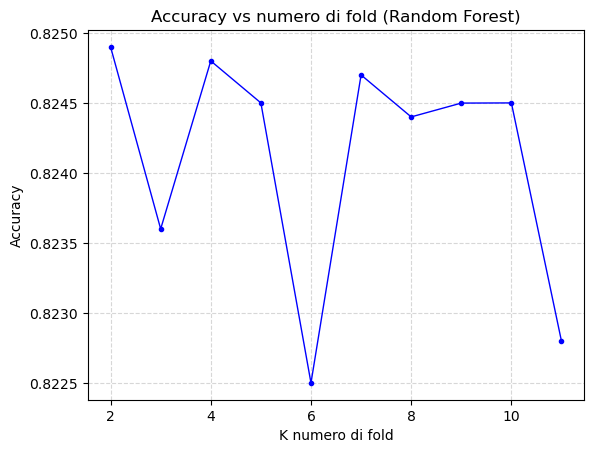

In [6]:
NUMK = 11

acc_numk = [] # array di accuracy in funzione di numvar

for numk in range(2, NUMK +1):
    
    skf = StratifiedKFold(n_splits=numk, shuffle=True, random_state=1)
    rf_model = RandomForestClassifier(class_weight={0: 1, 1: 2.5})
    
    acc_folds = []  # array di accuracy per un singolo fold
    
    for train_index, test_index in skf.split(data,labels):
        data_train, data_test = data[train_index], data[test_index]
        labels_train, labels_test = labels[train_index], labels[test_index]
        
        # fase di training
        rf_model.fit(data_train, labels_train)
        
        # fase di testing
        predictions = rf_model.predict(data_test)
        
        # confronta le previsioni con le soluzioni vere
        accuracy = accuracy_score(labels_test, predictions)
        
        # accuracy per questo fold
        acc_folds.append(accuracy)
        
    acc_numk.append(np.mean(acc_folds))

# --- Plot accuracy vs K numero di fold ---

plt.figure()
plt.plot(np.arange(2, NUMK+1), acc_numk, marker='o', color='b', linewidth=1, markersize=3)
plt.xlabel('K numero di fold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs numero di fold (Random Forest)')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.show()

Ora effettuiamo PCA per ridurre la dimensionalità dei dati, e osserviamo l'andamento dell'accuratezza in funzione della dimensionalità dei dati.

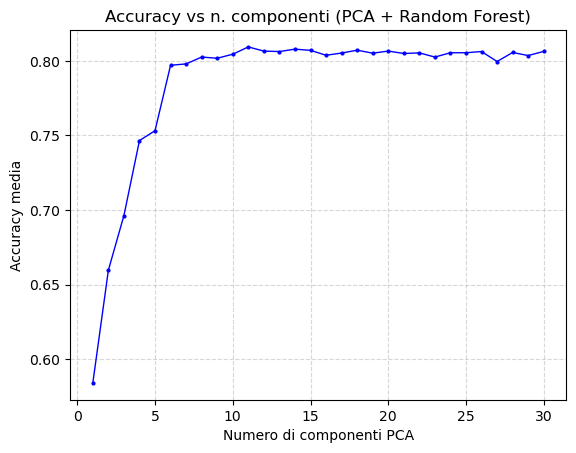

--------------------
MAX Accuracy:    80.71
MAX Sensitivity: 60.47
MAX Specificity: 91.01
Numero di componenti: 15
--------------------


In [11]:
K = 5
NUMDIM = 30

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=1)

acc_numdim = []   # array di accuracy in funzione di numvar = dimensione ridotta dei campioni tramite PCA
sens_numdim = []
spec_numdim = []

# --- Ciclo for su numvar = dimensione ridotta tramite PCA ---

for numdim in range(1, NUMDIM + 1):

    acc_folds = []   # array di accuracy per singolo fold
    sens_folds = []
    spec_folds = []

    for train_index, test_index in skf.split(data, labels):
        data_train, data_test = data[train_index], data[test_index]
        labels_train, labels_test = labels[train_index], labels[test_index]

        # PCA sul TRAIN (riduce a numvar componenti)
        pca = PCA(n_components = numdim)
        data_train_pca = pca.fit_transform(data_train)
        data_test_pca  = pca.transform(data_test) 

        # SVM lineare
        rf_model = RandomForestClassifier(class_weight={0: 1, 1: 2.5})
        
        # training
        rf_model.fit(data_train_pca, labels_train)
        
        # testing 
        predictions = rf_model.predict(data_test_pca)
        
        # metriche per questo fold
        acc  = accuracy_score(labels_test, predictions)
        sens = recall_score(labels_test, predictions, pos_label=1)
        spec = recall_score(labels_test, predictions, pos_label=0)

        acc_folds.append(acc)
        sens_folds.append(sens)
        spec_folds.append(spec)
    
    # medie sui K fold per questo numvar
    acc_numdim.append(np.mean(acc_folds))
    sens_numdim.append(np.mean(sens_folds))
    spec_numdim.append(np.mean(spec_folds))
    

plt.figure()
plt.plot(np.arange(1, NUMDIM + 1), acc_numdim, marker='o', color='b', linewidth=1, markersize=2)
plt.xlabel('Numero di componenti PCA')
plt.ylabel('Accuracy media')
plt.title('Accuracy vs n. componenti (PCA + Random Forest)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

# --- Risultati migliori ---
best_idx = 14
best_numdim = 15

print('--------------------')
print(f'MAX Accuracy:    {acc_numdim[best_idx]*100:.2f}')
print(f'MAX Sensitivity: {sens_numdim[best_idx]*100:.2f}')
print(f'MAX Specificity: {spec_numdim[best_idx]*100:.2f}')
print(f'Numero di componenti: {best_numdim}')
print('--------------------')

Varianza spiegata da ogni componente:

In [12]:
pca_best = PCA(n_components=best_numdim)
data_pca = pca_best.fit_transform(data)

print('--------------------')
print(f'Numero ottimale di componenti: {best_numdim}')
print('--------------------')

# --- Varianza spiegata da ogni componente ---
print('Varianza spiegata da ogni componente')
print('--------------------')
print(pca_best.explained_variance_ratio_)
print('--------------------')

# --- Varianza cumulativa ---
print('Varianza cumulativa')
print('--------------------')

cumulative_variance = np.cumsum(pca_best.explained_variance_ratio_)
print(cumulative_variance)
print('--------------------')                       # primo autovettore (lunghezza 32*509)

--------------------
Numero ottimale di componenti: 15
--------------------
Varianza spiegata da ogni componente
--------------------
[5.78434567e-01 2.96250785e-01 3.76468346e-02 3.04131023e-02
 1.74580336e-02 1.19971539e-02 8.05699202e-03 6.45763717e-03
 4.37697307e-03 3.62063883e-03 2.36366948e-03 1.47124003e-03
 1.25199051e-03 3.67357775e-05 3.41120789e-05]
--------------------
Varianza cumulativa
--------------------
[0.57843457 0.87468535 0.91233219 0.94274529 0.96020332 0.97220048
 0.98025747 0.98671511 0.99109208 0.99471272 0.99707639 0.99854763
 0.99979962 0.99983635 0.99987047]
--------------------


Plottiamo la prima componente principale e individuiamo i 5 canali più importanti.

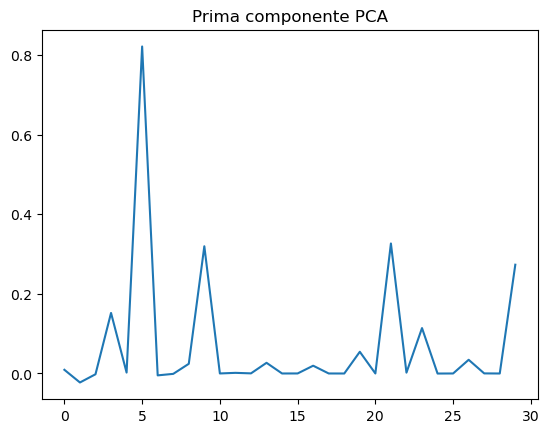

--------------------
Canali dei 5 coefficienti più grandi della prima componente principale: [ 5 21  9 29  3 23 19 26 13]
--------------------
Valori dei coefficienti: [0.82111446 0.32642761 0.31944744 0.27313616 0.15197696 0.11399717
 0.05447694 0.03438044 0.02679192]
--------------------


In [13]:
# --- Autovettori (componenti principali) ---
U = pca_best.components_  # (best_numvar, n_feature_originali)


v1 = U[0]  # primo autovettore

plt.plot(v1)
plt.title('Prima componente PCA')
plt.show()

# --- 

v1_ordered = np.argsort(v1)
indexes_max = v1_ordered[-9:][::-1]
dfg.head()
print('--------------------')
print(f'Canali dei 5 coefficienti più grandi della prima componente principale: {indexes_max}')
print('--------------------')
print(f'Valori dei coefficienti: {v1[indexes_max]}')
print('--------------------')

Zoom nell'intorno dei canali corrispondenti ai coefficienti massimi della prima componente.

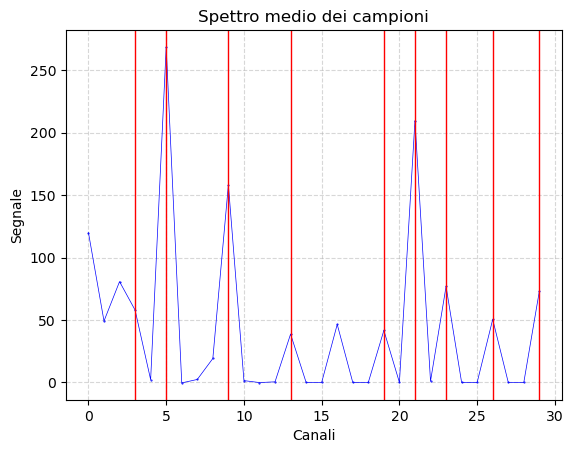

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


In [14]:
# --- Calcoliamo lo spettro medio del segnale B ---

spectrum_sum = data.sum(axis=0)
spectrum_mean = data.sum(axis=0) / (N0+N1)

# --- Plottiamo nell'intorno dei canali corrispondenti ai massimi ---
x = np.arange(0,30)
plt.figure()
plt.plot(x, spectrum_mean[x], marker='o', markersize=0.5, color='b', linewidth=0.5)

for index in indexes_max:
    plt.axvline(x=index, color='r', linewidth=1)
plt.xlabel('Canali')
plt.ylabel('Segnale')
plt.title('Spettro medio dei campioni')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()
dfg.head()